> Note: 2 runs per split * 5 splits per seed * 5 seeds per ratio * 8 ratios = 400 splits

## Plan
```python
for num_labelled in [2, 4, 8, ..., 256]:
    for seed in [1..5]:
        for split in [1..5]:
            run_fsl(num_labelled, seed, split)
            run_ssl(num_labelled, seed, split)
```
<br/>
- Each seed gives a different selection of labelled data
- The five splits are done on the same selection of labelled data

# Imports

In [1]:
import tensorflow as tf
from tensorflow_examples.models.pix2pix import pix2pix
import keras
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import nibabel as nib
import random
from sklearn.model_selection import KFold
import datetime
import time
import os

# Config

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

tf.config.set_logical_device_configuration(
    gpus[0],
    [tf.config.LogicalDeviceConfiguration(memory_limit=8192)]
)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

# Constants

In [3]:
# Global Hyperparameters
CROSS_VAL_K = 5
TRAINING_DATA_PATH = "training-data/{}/BraTS20_Training_{:03}{}.nii"
LABELLED_BATCH_SIZE = 32
UNLABELLED_BATCH_SIZE = 32

# Run-Specific Hyperparameters
NUM_LABELLED = 16
CROSS_VAL_SPLIT = 0; assert 0 <= CROSS_VAL_SPLIT < CROSS_VAL_K
DATASET_SEED = 0

# Definitions

In [4]:
def get_paths_from_id(id: int) -> tuple[str, str]:
    """Get path to inputs volume and segmented volume by case ID.

    Args:
        id (int): ID of the volume, ranging from 1-369.

    Returns:
        tuple[str,str]: A tuple with the inputs path first and the
        segmentation path second
    """    
    return TRAINING_DATA_PATH.format('input', id, ''), TRAINING_DATA_PATH.format('seg', id, '_seg')

def load_nii(path: str) -> npt.NDArray[np.float32]:
    """Load a Nifti file (as `float32`)

    Args:
        path (str): Path to the Nifti file

    Returns:
        npt.NDArray[np.float32]: The loaded `nibabel` object
    """    
    return nib.load(path).get_fdata().astype(np.float32)

def load_volume(
    id: int
) -> tuple[npt.NDArray[np.float32], npt.NDArray[np.float32]]:
    """Load a volume by case ID

    Args:
        id (int): The case ID of the volume

    Returns:
        tuple[npt.NDArray[np.float32], npt.NDArray[np.float32]]: The loaded
        volume's inputs (t1, t1ce, t2 as channels), and the segmentation mask
    """    
    inputs_path, seg_path = get_paths_from_id(id)    
    x = load_nii(inputs_path)
    y = load_nii(seg_path) # (H, W, D)
    return x, y

def labelled_slice_generator(volume_ids: npt.ArrayLike):
    """Generate labelled slices from volumes with the given IDs

    Args:
        volume_ids (npt.ArrayLike): List of case IDs (integers 1-369)

    Yields:
        tuple[int,int,npt.NDArray[np.float32],npt.NDArray[np.float32]]: The loaded
        volumes' ID, the z-coord of the slice, the inputs (t1, t1ce, t2 as channels),
        and the segmentation mask
    """    
    for id in np.asarray(volume_ids):
        x, y = load_volume(id)  # (H,W,D,4), pre-preprocessed
        for z in range(x.shape[2]):
            yield id, z, x[:, :, z, 1:], y[:, :, z]
            
def unlabelled_slice_generator(volume_ids: npt.ArrayLike):
    """Generate unlabelled slices from volumes with the given IDs

    Args:
        volume_ids (npt.ArrayLike): List of case IDs (integers 1-369)

    Yields:
        tuple[int,int,npt.NDArray[np.float32]]: The loaded volumes' ID, the z-coord
        of the slice, the inputs (t1, t1ce, t2 as channels)
    """    
    for id in np.asarray(volume_ids):
        x, _y = load_volume(id)  # (H,W,D,4), pre-preprocessed
        for z in range(x.shape[2]):
            yield id, z, x[:, :, z, 1:]
            
def volume_generator(volume_ids: npt.ArrayLike):
    """Generate slices from volumes with the given IDs

    Args:
        volume_ids (npt.ArrayLike): List of case IDs (integers 1-369)

    Yields:
        tuple[npt.NDArray[np.float32],npt.NDArray[np.float32]]: The loaded
        volumes' inputs (t1, t1ce, t2 as channels) first, and the segmentation
        masks second
    """    
    for id in np.asarray(volume_ids):
        x, y = load_volume(id)  # (H,W,D,4), pre-preprocessed
        yield x[..., 1:], y

def plot_slice(
    input: npt.NDArray[np.float32],
    seg1: npt.NDArray[np.float32],
    seg2: npt.NDArray[np.float32] | None = None,
    title: str | None = None
) -> None:
    """Plot the modalities of a slice from a volume.

    Args:
        input (npt.NDArray[np.float32]): The input modalities, in numpy form.
        seg (npt.NDArray[np.float32]): The segmentation to plot alongside the input.
        title (str, optional): The title of the plot. Defaults to None.
    """    
    orig = input.copy()
    input -= input.min(axis=(0,1))
    input /= input.max(axis=(0,1))
    input[orig == 0.0] = 0.0
    
    cols = 3 if isinstance(seg2, np.ndarray) else 2
    fig, axes = plt.subplots(
        1, cols,
        figsize=(4*cols, 4),
        constrained_layout=True
    )
    
    ax1, ax2 = axes[0:2]
    ax1.imshow(input)
    ax1.axis("off")
    ax1.set_title("Inputs")
    ax2.imshow(seg1)
    ax2.axis("off")
    ax2.set_title("Ground Truth")
    
    ax1.scatter([], [], label="T1", c='r')
    ax1.scatter([], [], label="T1ce", c='g')
    ax1.scatter([], [], label="T2", c='b')
    ax1.legend(loc="lower right", frameon=True)
    
    if cols == 3:
        ax3 = axes[2]
        ax3.imshow(seg2)
        ax3.axis("off")
        ax3.set_title("Prediction")
        
    if title is not None:
        fig.suptitle(title)

def unet_model(output_channels:int) -> keras.Model:
    """Create a U-Net model with pretrained weights and specified number of segmentation classes.

    Args:
        output_channels (int): The number of segmentation classes (i.e., logits in the output layer)

    Returns:
        keras.Model: The U-Net model object
    """    
    base_model: keras.Model = keras.models.load_model(
        "base_model.keras",
        custom_objects=None, compile=True)  # type: ignore

    # Use the activations of these layers
    layer_names = [
        'block_1_expand_relu',   # 64x64
        'block_3_expand_relu',   # 32x32
        'block_6_expand_relu',   # 16x16
        'block_13_expand_relu',  # 8x8
        'block_16_project',      # 4x4
    ]
    base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

    # Create the feature extraction model
    down_stack = keras.Model(inputs=base_model.input, outputs=base_model_outputs)
    # down_stack.trainable = False

    up_stack = [
        pix2pix.upsample(512, 3),  # 4x4 -> 8x8
        pix2pix.upsample(256, 3),  # 8x8 -> 16x16
        pix2pix.upsample(128, 3),  # 16x16 -> 32x32
        pix2pix.upsample(64, 3),   # 32x32 -> 64x64
    ]
    inputs = keras.layers.Input(shape=[128, 128, 3]) 

    # Downsampling through the model
    skips = down_stack(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        concat = keras.layers.Concatenate()
        x = concat([x, skip])

    # This is the last layer of the model
    last = keras.layers.Conv2DTranspose( 
        filters=output_channels, kernel_size=3, strides=2,
        padding='same')  #64x64 -> 128x128

    x = last(x)

    return keras.Model(inputs=inputs, outputs=x)

def get_split(
    num_labelled: int,
    seed: int,
    cross_val_split: int
) -> dict[str, npt.NDArray[np.int32]]:
    """Get the volume IDs for the split with given parameters.
    Deterministic and pseudo-random.

    Args:
        num_labelled (int): The number of labelled volumes.
        seed (int): The seed for shuffling the volumes.
        cross_val_split (int): Which k-fold validation split to run.

    Returns:
        dict[str,npt.NDArray[np.int32]]: Dict containing
        `"labelled", "unlabelled" and "val"` volume IDs
    """    
    rng = random.Random(seed)
    volume_ids = list(range(1, 370))
    rng.shuffle(volume_ids)

    labelled_ids = np.array(volume_ids[:num_labelled], dtype=np.int32)
    remaining_ids = np.array(volume_ids[num_labelled:], dtype=np.int32)
    splits = [
        {
            "labelled": labelled_ids,
            "unlabelled": remaining_ids[train_idx],
            "val": remaining_ids[val_idx]
        }
        for train_idx, val_idx in KFold(n_splits=CROSS_VAL_K).split(remaining_ids)
    ]
    
    split = splits[cross_val_split]
    
    return split

class DiceCoefficient(keras.metrics.Metric):
    """Dice coefficient metric.
    """    
    def __init__(self, name="dice_coef", smooth=1e-6, **kwargs):
        """Create a metric object to track Dice coefficient.

        Args:
            name (str, optional): The name of the metric. Defaults to "dice_coef".
            smooth (_type_, optional): Smoothing to prevent division by zero. Defaults to 1e-6.
        """
        super(DiceCoefficient, self).__init__(name=name, **kwargs)
        self.smooth = smooth
        self.dice_sum = self.add_weight(name="dice_sum", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        """Update the metric.

        Args:
            y_true (Tensor): The ground truth, sparse-encoded.
            y_pred (Tensor): The model prediction, still in logit form.
        """        
        y_pred = tf.nn.softmax(y_pred, axis=-1)
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
        y_pred = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
        y_true = tf.reshape(y_true, [-1, tf.shape(y_pred)[-1]])
        
        intersection = tf.reduce_sum(y_true * y_pred, axis=0)
        union = tf.reduce_sum(y_true, axis=0) + tf.reduce_sum(y_pred, axis=0)
        dice = tf.reduce_mean((2.0 * intersection + self.smooth) / (union + self.smooth))
        
        self.dice_sum.assign_add(dice)
        self.count.assign_add(1.0)
    
    def result(self):
        """Get the metric's value

        Returns:
            Tensor: The metric's value
        """
        return self.dice_sum / self.count

    def reset_state(self):
        """Reset the metric
        """
        self.dice_sum.assign(0.0)
        self.count.assign(0.0)

# Dataset Preparation

In [5]:
split = get_split(NUM_LABELLED, DATASET_SEED, CROSS_VAL_SPLIT)
print("\n\n".join([f"{k}: {v}" for k,v in split.items()]))

output_signature = (
    tf.TensorSpec(shape=(), dtype=tf.uint32),
    tf.TensorSpec(shape=(), dtype=tf.uint32),
    tf.TensorSpec(shape=(128, 128, 3), dtype=np.float32),
    tf.TensorSpec(shape=(128, 128), dtype=np.float32)
)

# Data in format: (id, z, input, seg)
# Filter out background-only slices from labelled dataset
labelled_ds = tf.data.Dataset.from_generator(
    lambda: labelled_slice_generator(split['labelled']),
    output_signature=output_signature
).filter(
    lambda id, z, input, seg: tf.reduce_mean(seg) > 1e-6
).cache().shuffle(buffer_size=1024)

# Data in format: (id, z, input)
unlabelled_ds = tf.data.Dataset.from_generator(
    lambda: unlabelled_slice_generator(split['unlabelled']),
    output_signature=output_signature[:-1]
).cache().shuffle(buffer_size=1024)

# Data in format: (id, z, input, seg)
val_ds = tf.data.Dataset.from_generator(
    lambda: labelled_slice_generator(split['val']),
    output_signature=output_signature
).shuffle(buffer_size=1024)

labelled_batches = labelled_ds.batch(LABELLED_BATCH_SIZE).prefetch(2)
unlabelled_batches = unlabelled_ds.batch(UNLABELLED_BATCH_SIZE).repeat().prefetch(2)
val_batches = val_ds.take(256).cache().batch(LABELLED_BATCH_SIZE).prefetch(2)

labelled: [117 270 160 297 332 263 161 168 207 264  93  75 350  29  83 119]

unlabelled: [363  82  71  25 116 310 365 235 260 300 293 135 128 194 237  63  68 248
 344 152 224 257 130  22 305 127  85  99 122 154 193 238 340   5 247 192
 312  87 113 143 286 115  58 355 176 301 343 323 151 107 157 282  34 158
  74  91 289  62  35 354 203 239 364 367 118 307 144  40 169 100 212  80
 131 178 296 241   4  45 322 186 339  65 136  88 276  41  15  53 173 306
 146 271  92 199 341 222 180 200 153  11 120 351 206 292 358  90  78 166
 331 240  18 311 333 347 109 140 274 174 246 325 187  54 337 229 360 326
  50   6 226  10 255 214 342  24 101  31 294 213 362 353 236 329   7  19
 175 303 137 233 290 147 210  12 266 179 219 345 275  26  16 209 110  86
  44 204 285  57 181  30 139   9 319 316 172 250  60 318  43 183 324 231
 141 215 111 121 268 142 269 201 308  20  77  67  46  36 244 330  17  96
  97  95 149 124 163 369 349 228 148 359 335 277 320 336  64 150 334 155
  56 251 261 164  42  47 230 279  7

I0000 00:00:1766025889.083473  850261 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1766025889.083517  850261 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


# Model Instantiation

In [6]:
model = unet_model(output_channels=2)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# Logging

In [7]:
metrics = {
    (l:="train_loss_supervised"):  keras.metrics.Mean(l, dtype=tf.float32),
    (l:="val_loss_supervised"):    keras.metrics.Mean(l, dtype=tf.float32),
    (l:="train_loss_consistency"): keras.metrics.Mean(l, dtype=tf.float32),
    (l:="train_loss_total"):       keras.metrics.Mean(l, dtype=tf.float32),
    (l:="train_acc"):              keras.metrics.SparseCategoricalAccuracy(l),
    (l:="val_acc"):                keras.metrics.SparseCategoricalAccuracy(l),
    (l:="train_dice"):             DiceCoefficient(l),
    (l:="val_dice"):               DiceCoefficient(l),
    (l:="time_step"):              keras.metrics.Mean(l, dtype=tf.uint64),
    (l:="time_epoch"):             keras.metrics.Mean(l, dtype=tf.uint64)
}

current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_log_dir = f'logs/gradient_tape/{current_time}/train'
val_log_dir = f'logs/gradient_tape/{current_time}/val'
perf_log_dir = f'logs/gradient_tape/{current_time}/perf'
train_writer = tf.summary.create_file_writer(train_log_dir)
val_writer   = tf.summary.create_file_writer(val_log_dir)
perf_writer  = tf.summary.create_file_writer(perf_log_dir)

def write_train_summary(epoch, consistency_weight):
    with train_writer.as_default():
        tf.summary.scalar("consistency_weight", consistency_weight, step=epoch)
        tf.summary.scalar("supervised_loss",    metrics["train_loss_supervised"].result(), step=epoch)
        tf.summary.scalar("consistency_loss",   metrics["train_loss_consistency"].result(), step=epoch)
        tf.summary.scalar("total_loss",         metrics["train_loss_total"].result(), step=epoch)
        tf.summary.scalar("accuracy",           metrics["train_acc"].result(), step=epoch)
        tf.summary.scalar("dice",               metrics["train_dice"].result(), step=epoch)
        
def write_val_summary(epoch, duration):
    with val_writer.as_default():
        tf.summary.scalar("supervised_loss",    metrics["val_loss_supervised"].result(), step=epoch)
        tf.summary.scalar("accuracy",           metrics["val_acc"].result(), step=epoch)
        tf.summary.scalar("dice",               metrics["val_dice"].result(), step=epoch)
        
    with perf_writer.as_default():
        tf.summary.scalar("val_time_ns", duration, step=epoch)
        
def write_step_summary(epoch, duration):
    with perf_writer.as_default():
        tf.summary.scalar("step_time_ns", duration, step=epoch)
    
    
def write_epoch_summary(epoch, duration):
    with perf_writer.as_default():
        tf.summary.scalar("epoch_time_ns", duration, step=epoch)
    
    

# Training Definitions

In [8]:
supervised_loss_func = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
inner_unsupervised_loss_func = keras.losses.Dice()

@tf.function
def consistency_loss_func(xu, num_channels=3):
    """Calculate the consistency loss on a batch `xu` of unlabelled slices.

    Args:
        xu (_batch_): A batch of unlabelled slices
        num_channels (int, optional): The number of modalities. Defaults to 3.

    Returns:
        tf.float32: The consistency loss. May be a symbolic tensor.
    """    
    preds = []
    for ch in range(num_channels):
        mask = tf.one_hot(ch, num_channels)
        mask = tf.reshape(mask, (1,1,1,num_channels))
        x_masked = xu * mask
        p = model(x_masked, training=True)
        preds.append(tf.nn.softmax(p, axis=-1))

    preds = tf.stack(preds, axis=0)
    ref = tf.stop_gradient(tf.reduce_mean(preds, axis=0))
    return tf.reduce_mean(tf.map_fn(
        lambda p: inner_unsupervised_loss_func(ref, p),
        preds
    ))

@tf.function
def step(xl, yl, xu, consistency_weight):
    """Train the model for one step using a batch of data.

    Args:
        xl (_batch_): A batch of labelled slice inputs
        yl (_batch_): A batch of labels for `xl`
        xu (_batch_): A batch of unlabelled slices
        consistency_weight (tf.float32): How much the consistency loss should contribute to the total loss.
    """    
    with tf.GradientTape() as tape:
        pred = model(xl, training=True)
        supervised_loss = supervised_loss_func(yl, pred)
        consistency_loss = consistency_loss_func(xu)
        loss = supervised_loss + consistency_weight * consistency_loss
        
    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    
    metrics["train_loss_supervised"](supervised_loss)
    metrics["train_loss_consistency"](consistency_loss)
    metrics["train_loss_total"](loss)
    metrics["train_acc"](yl, pred)
    metrics["train_dice"](yl, pred)

@tf.function
def val_step(x, y):
    """Evaluate the model on a batch of validation slices.

    Args:
        x (_batch_): A batch of slice inputs - will be used for both supervised and consistency loss.
        y (_batch_): Labels for the slices `x`.
        consistency_weight (tf.float32): How much the consistency loss should contribute to the total loss.
    """    
    pred = model(x, training=False)
    loss = supervised_loss_func(y, pred)
    
    metrics["val_loss_supervised"](loss)
    metrics["val_acc"](y, pred)
    metrics["val_dice"](y, pred)
    

# Training Loop

In [9]:
unlabelled_batches = iter(unlabelled_batches)
weight_schedule = [0.0, 0.02, 0.02]

for epoch, consistency_weight in enumerate(weight_schedule):
    print(f"Epoch {epoch}, consistency weight = {consistency_weight}")
    start_epoch = time.perf_counter_ns()
    
    for batch_num, (_id, _z, xl, yl) in enumerate(labelled_batches):
        start_step = time.perf_counter_ns()
        unlabelled_batch = next(unlabelled_batches)
        if unlabelled_batch is None:
            raise RuntimeError("Unlabelled data pipeline error.")
        
        _id, _z, xu = unlabelled_batch
        step(xl, yl, xu, consistency_weight)
        write_step_summary(epoch, time.perf_counter_ns() - start_step)
        
    write_train_summary(epoch, consistency_weight)
        
    print(f"\tEpoch training done\n\tStarting validation")
    start_val = time.perf_counter_ns()
    for val_batch_num, (_id, _z, x, y) in enumerate(val_batches):
        val_step(x, y)
        
    write_val_summary(epoch, time.perf_counter_ns() - start_val)
    write_epoch_summary(epoch, time.perf_counter_ns() - start_epoch)

    for metric in metrics.values():
        metric.reset_state()

Epoch 0, consistency weight = 0.0
	Epoch training done
	Starting validation
Epoch 1, consistency weight = 0.02
	Epoch training done
	Starting validation
Epoch 2, consistency weight = 0.02
	Epoch training done
	Starting validation


# Validation

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


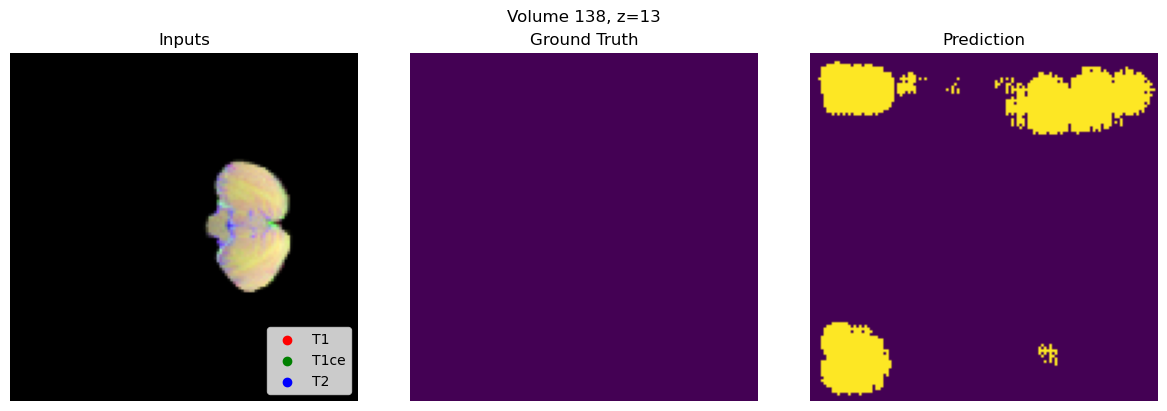

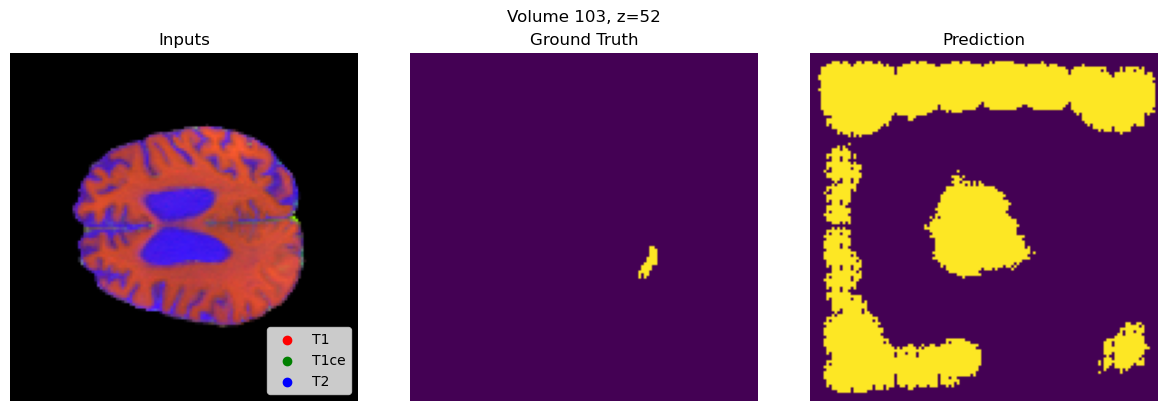

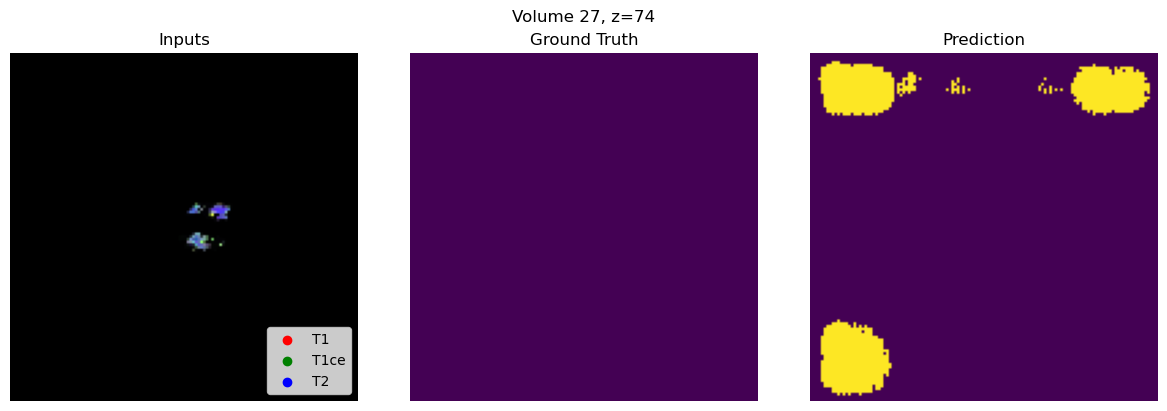

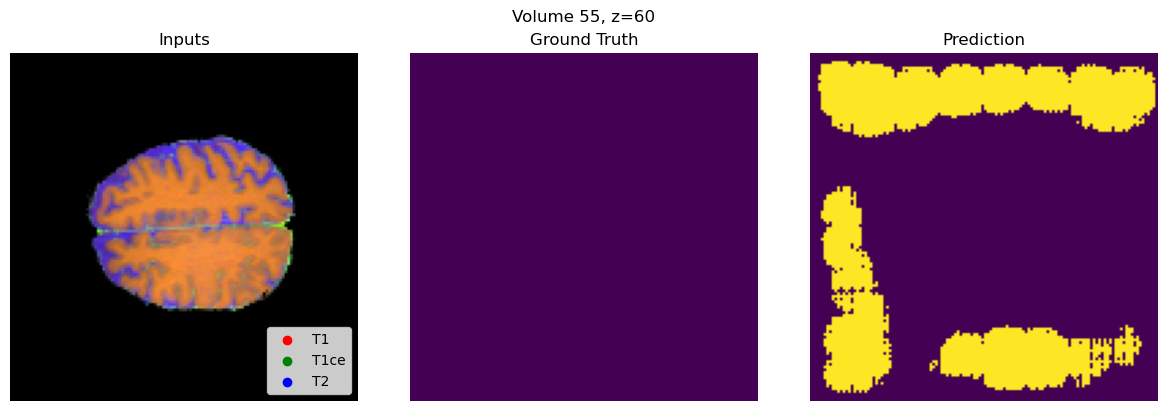

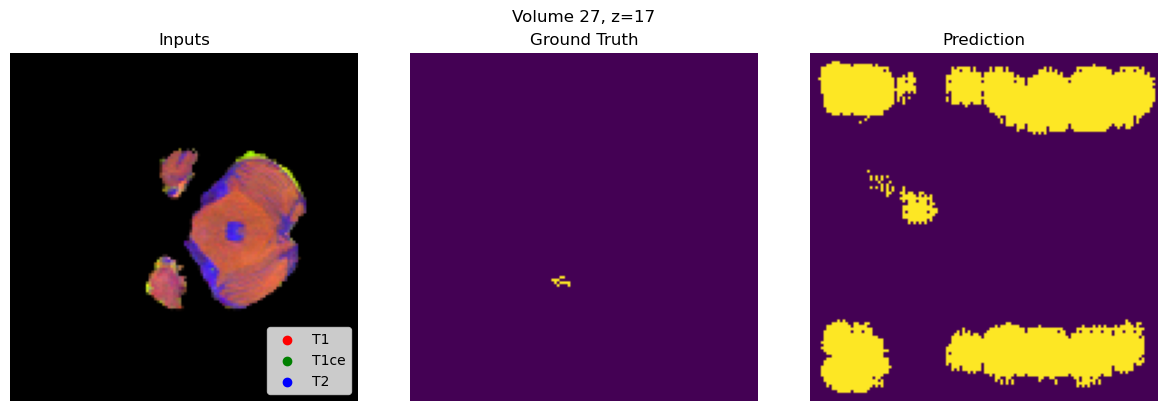

In [10]:
for i, (id, z, input, seg) in enumerate(val_ds.take(5)):
    pred = model.predict(np.expand_dims(input, axis=0))[0]
    plot_slice(
        input.numpy(),
        seg.numpy(),
        pred.argmax(axis=-1),
        title=f"Volume {id}, z={z}"
    )